# 01 — Exploratory Data Analysis (canonical EDA)
### Remixability thesis · ccMixter remix-lineage dataset

This notebook re-derives every data-quality finding from the **raw** files with our own code, so the numbers are auditable. It is **read-only**; cleaning happens in `02_preprocess.ipynb`. Figures are saved to `figures/`.

This is the EDA used in the thesis. `01_eda.ipynb` is an earlier draft kept for the record.

**Sections**
1. First look — shape, columns, types
2. Missingness — which columns are usable
3. Temporal coverage
4. Engagement columns — `score` / `num_scores` / `thumbs_up`
5. ⭐ Outcome and **label source** — edges vs the `n_remixes` column
6. Graph structure — DAG check, cascade depth, components
7. Right-censoring — evidence for the horizon decision
8. Removed-edge audit
9. Edge-set integrity
10. Summary — decisions carried into `02`

**Headline numbers**
- 51,486 tracks and 59,186 local remix edges;
- 36.4 % of tracks ever remixed;
- 91.5 % of remixes within two generations of an original;
- a giant component holding 76.3 % of tracks.

## 0. Setup

In [1]:
import json
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
BLUE, RED = "#2a78d6", "#c0392b"

# === CONFIG — point this at your local data/processed folder =================
DATA   = Path("data/processed")          # <- change if your path differs
FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)

nodes   = pd.read_csv(DATA / "nodes.csv")
edges   = pd.read_csv(DATA / "edges.csv")
removed = pd.read_csv(DATA / "edges_removed.csv")
summary = json.loads((DATA / "summary.json").read_text())

N = len(nodes)
print("nodes:", nodes.shape, "| edges:", edges.shape, "| removed:", removed.shape)
print("versions -> pandas", pd.__version__, "| networkx", nx.__version__)

nodes: (51486, 21) | edges: (62300, 8) | removed: (684, 9)
versions -> pandas 3.0.5 | networkx 3.6.1


## 1. First look — shape, columns, types

In [2]:
display(nodes.head())
print(nodes.dtypes)
print("\nunique tracks:", nodes["upload_id"].nunique(), "of", len(nodes), "rows")
print("duplicate upload_id:", int(nodes["upload_id"].duplicated().sum()))

,upload_id,user_name,user_id,user_real_name,name,date_iso,date_unix,year,license,license_url,score,num_scores,num_playlists,thumbs_up,num_files,n_remixes,n_sources,usertags,systags,page_url,has_meta
0,41,wired,NaN,WIRED Magazine CD,Wired Loop Example,2004-10-28T01:20:00+00:00,1098926400,NaN,Noncommercial Sampling Plus,http://creativecommons.org/licenses/nc-samplin...,400.0,3.0,NaN,1,6,0,5,"bass,guitar,kawai,saxophone,vocals","nc_sampling_plus,audio,mp3,44k,stereo,VBR,arch...",https://ccmixter.org/files/wired/41,False
1,42,wired,NaN,WIRED Magazine CD,Wired Loops 01 (sampling+),2004-10-28T01:20:00+00:00,1098926400,NaN,Sampling Plus,http://creativecommons.org/licenses/sampling+/...,NaN,1.0,NaN,1,1,1,0,"female_vocals,jazz,saxophone","sampling_plus,archive,zip",https://ccmixter.org/files/wired/42,False
2,43,wired,NaN,WIRED Magazine CD,Wired Loops 02 (sampling+),2004-10-28T01:20:00+00:00,1098926400,NaN,Sampling Plus,http://creativecommons.org/licenses/sampling+/...,NaN,NaN,NaN,1,1,2,0,saxophone,"sampling_plus,archive,zip",https://ccmixter.org/files/wired/43,False
3,44,wired,NaN,WIRED Magazine CD,Wired Loops 03 (sampling+),2004-10-28T01:20:00+00:00,1098926400,NaN,Sampling Plus,http://creativecommons.org/licenses/sampling+/...,NaN,NaN,NaN,1,1,3,0,"12_string,bandeon,bass,female_vocals,guitar,sa...","sampling_plus,archive,zip",https://ccmixter.org/files/wired/44,False
4,45,wired,NaN,WIRED Magazine CD,Wired Loops 04 (sampling+),2004-10-28T01:20:00+00:00,1098926400,NaN,Sampling Plus,http://creativecommons.org/licenses/sampling+/...,NaN,NaN,NaN,1,1,1,0,"brass,brazil,calmantes,canastra,independent,me...","sampling_plus,archive,zip",https://ccmixter.org/files/wired/45,False


upload_id           int64
user_name             str
user_id           float64
user_real_name        str
name                  str
date_iso              str
date_unix           int64
year              float64
license               str
license_url           str
score             float64
num_scores        float64
num_playlists     float64
thumbs_up           int64
num_files           int64
n_remixes           int64
n_sources           int64
usertags              str
systags               str
page_url              str
has_meta             bool
dtype: object

unique tracks: 51486 of 51486 rows
duplicate upload_id: 0


**Interpretation.** All 51,486 rows are unique tracks (no duplicate `upload_id`).

- **Identifiers:** `upload_id`, `user_name`, `user_real_name`, `name` and `page_url`.
- **Time:** `date_iso` and `date_unix`.
- **Candidate post-time inputs:** `license` / `license_url`, `num_files`, `n_sources`, `usertags` and `systags`.
- **Outcome or snapshot values:** `n_remixes` (the site's remix counter today) and the engagement columns (`score`, `num_scores`, `num_playlists`, `thumbs_up`). These describe a track *now*, not at upload, so they cannot be prediction features.
- **Unclear meaning:** `score` (range 100–500) is undocumented. `systags` mixes technical tokens (format, bitrate) with curatorial ones such as `editorial_pick`, whose timing is unknown.

## 2. Missingness — which columns are usable?

,percent_null
num_playlists,100.0
user_id,100.0
year,100.0
score,90.1
num_scores,8.8
usertags,5.5
page_url,0.0
systags,0.0
n_sources,0.0
n_remixes,0.0


100% null: ['user_id', 'year', 'num_playlists'] 
constant : ['thumbs_up', 'has_meta']


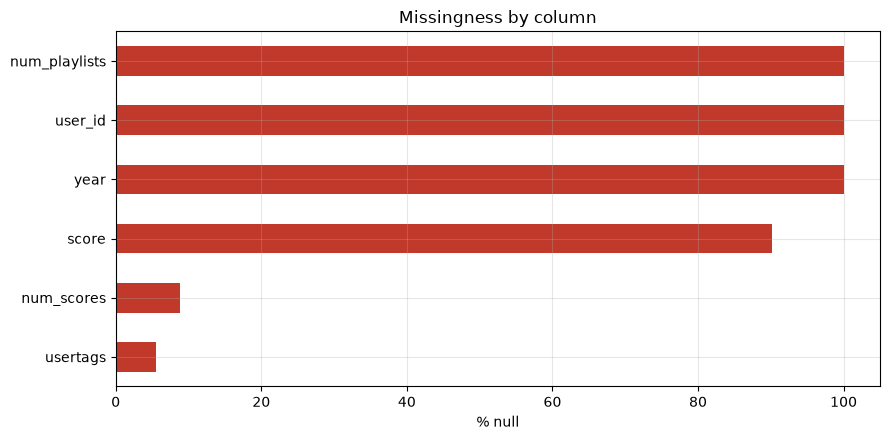

In [3]:
miss = (nodes.isna().mean() * 100).round(1).sort_values(ascending=False)
miss.name = "percent_null"
display(miss.to_frame())

dead_null     = [c for c in nodes.columns if nodes[c].isna().all()]
dead_constant = [c for c in nodes.columns if nodes[c].nunique(dropna=True) <= 1 and not nodes[c].isna().all()]
print("100% null:", dead_null, "\nconstant :", dead_constant)

ax = miss[miss > 0].plot.barh(color=RED)
ax.set_xlabel("% null"); ax.set_title("Missingness by column"); ax.invert_yaxis()
plt.tight_layout(); plt.savefig(FIGDIR / "missingness.png", dpi=120); plt.show()

**Interpretation.**
- **Fully empty:** `user_id`, `year` and `num_playlists` are 100 % null. The dataview used by the crawler does not expose them. Dropping them loses nothing: author identity is fully carried by `user_name`, and the date by `date_iso` / `date_unix`.
- **Constant:** `thumbs_up` (always 1) and `has_meta` (always False) carry no information.
- **Mostly empty:** `score` is 90.1 % null and is dropped (see §4).
- **Partly empty and kept:** `num_scores` (8.8 % null; see §4) and `usertags` (5.5 % null, meaning the uploader added no tags; encoded as an empty tag set with a `has_usertags` flag).

## 3. Temporal coverage — the backbone of RQ2

parse failures: 0
min: 2004-10-28 01:20:00+00:00 | max: 2026-07-20 21:30:00+00:00
in the future: 0


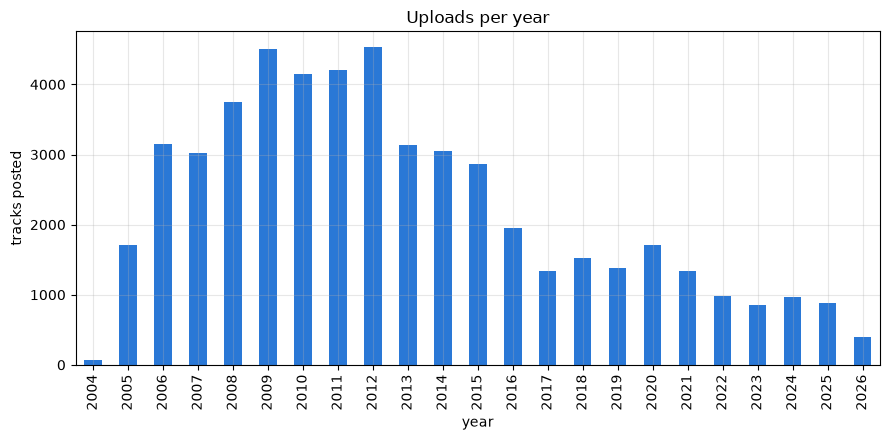

date_iso
2019    1381
2020    1714
2021    1333
2022     987
2023     858
2024     961
2025     885
2026     397
Name: count, dtype: int64

In [4]:
d = pd.to_datetime(nodes["date_iso"], errors="coerce", utc=True)
print("parse failures:", int(d.isna().sum()))
print("min:", d.min(), "| max:", d.max())
print("in the future:", int((d > pd.Timestamp.now(tz='UTC')).sum()))

by_year = d.dt.year.value_counts().sort_index()
ax = by_year.plot.bar(color=BLUE)
ax.set_xlabel("year"); ax.set_ylabel("tracks posted"); ax.set_title("Uploads per year")
plt.tight_layout(); plt.savefig(FIGDIR / "uploads_per_year.png", dpi=120); plt.show()
display(by_year.tail(8))

**Interpretation.** Every date parses, and none lies in the future. The data span 28 Oct 2004 to 20 Jul 2026.

- **Growth:** activity rose quickly from 2005 (1,716 uploads) and peaked in 2009–2012 (4,100–4,500 uploads per year).
- **Decline:** uploads fell steadily after 2012, to about 1,300–1,700 a year in 2017–2021 and under 1,000 a year from 2022. 2026 is a partial year (397 tracks up to the crawl date).

The thin recent years matter for the design:
- The temporal test set (2022 onwards) is small, 3,330 tracks.
- Recent tracks have had little time to be remixed. This right-censoring is quantified in §7.

## 4. Engagement columns — what's real, what's noise?

In [5]:
for col in ["score", "num_scores", "num_playlists", "thumbs_up", "num_files"]:
    s = pd.to_numeric(nodes[col], errors="coerce")
    print(f"{col:14} null%={nodes[col].isna().mean()*100:5.1f}  "
          f"min={s.min()}  max={s.max()}  mean={s.mean():.2f}  nunique={s.nunique()}")

sc = pd.to_numeric(nodes["score"], errors="coerce")
ns = pd.to_numeric(nodes["num_scores"], errors="coerce")
print("\n-- score coverage --")
print("tracks with num_scores>0 :", int((ns > 0).sum()))
print("tracks with score present:", int(sc.notna().sum()))
print("score present AND rated  :", int((sc.notna() & (ns > 0)).sum()))
# true-zero diagnostic for num_scores nulls
print("\nof num_scores-null rows, share also score-null:",
      round(nodes.loc[nodes.num_scores.isna(), "score"].isna().mean(), 3))

score          null%= 90.1  min=100.0  max=500.0  mean=430.90  nunique=116
num_scores     null%=  8.8  min=1.0  max=251.0  mean=9.51  nunique=94
num_playlists  null%=100.0  min=nan  max=nan  mean=nan  nunique=0
thumbs_up      null%=  0.0  min=1  max=1  mean=1.00  nunique=1
num_files      null%=  0.0  min=1  max=99  mean=1.87  nunique=46

-- score coverage --
tracks with num_scores>0 : 46980
tracks with score present: 5113
score present AND rated  : 3884

of num_scores-null rows, share also score-null: 0.727


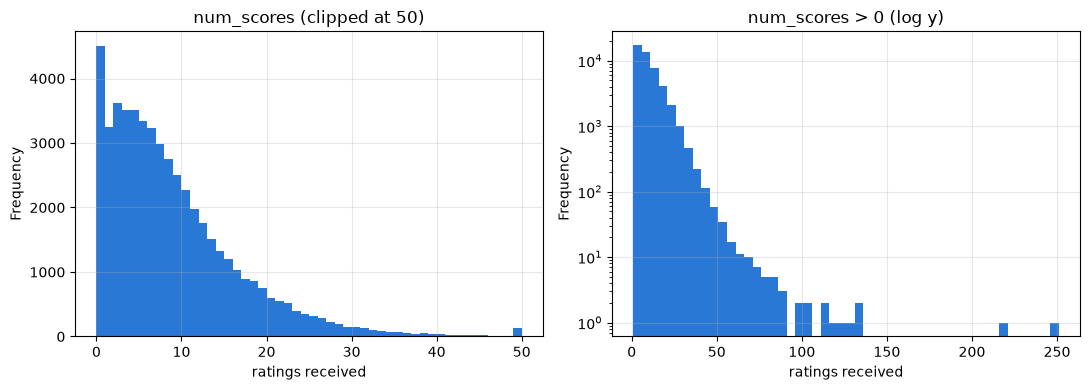

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ns.fillna(0).clip(upper=50).plot.hist(bins=50, ax=axes[0], color=BLUE)
axes[0].set_title("num_scores (clipped at 50)"); axes[0].set_xlabel("ratings received")
ns[ns > 0].plot.hist(bins=50, ax=axes[1], color=BLUE, log=True)
axes[1].set_title("num_scores > 0 (log y)"); axes[1].set_xlabel("ratings received")
plt.tight_layout(); plt.savefig(FIGDIR / "num_scores_dist.png", dpi=120); plt.show()

**Interpretation.**
- **`num_scores` is kept** as the only usable engagement count. Whenever it is present, its minimum is 1, and the key is missing when a track has no ratings. A null therefore means zero, and `02` fills it with 0 and records a flag.
  - It is a snapshot of *today's* value, so it is a popularity confound. It is **not** used as a prediction feature.
- **`score` is dropped.** It is 90.1 % null, takes values 100–500, looks like a sparse rating rather than a count, and is present on only 5,113 tracks.
- **`thumbs_up` is dropped** (constant 1), and so is **`num_playlists`** (always empty).
- **`num_files`** (mean 1.87, max 99) is complete and fixed at upload, so it is a valid feature.

## 5. ⭐ Outcome and label source — edges vs the `n_remixes` column

There are two ways to answer *"was this track remixed?"*:
- the convenient `n_remixes >= 1` column, or
- the cleaned **local** edge graph (out-degree > 0).

They disagree. The column is ccMixter's raw *current* count, while every graph-derived positive has a real, dated child track. The time-based features and horizon labels depend on that date, so **the label comes from the graph**.

In [7]:
local = edges[edges["edge_type"] == "local"]
G = nx.DiGraph()
G.add_nodes_from(nodes["upload_id"].astype(int))
G.add_edges_from(local[["parent_id", "child_id"]].astype(int).itertuples(index=False, name=None))

out_deg = pd.Series(dict(G.out_degree())).reindex(nodes["upload_id"]).fillna(0).astype(int)
is_remixed = (out_deg > 0)
print("edge-derived is_remixed (LOCAL): %d  base rate %.4f  (target 0.3645)"
      % (is_remixed.sum(), is_remixed.mean()))

edge-derived is_remixed (LOCAL): 18766  base rate 0.3645  (target 0.3645)


In [8]:
# --- resolve the discrepancy against the raw column ---
node_ids       = set(nodes["upload_id"])
parents_local  = set(out_deg[out_deg > 0].index)
parents_all    = set(edges["parent_id"]) & node_ids
col_remixed    = set(nodes.loc[nodes["n_remixes"] >= 1, "upload_id"])

print("edge-derived LOCAL : %5d  (%.4f)" % (len(parents_local), len(parents_local)/N))
print("edge-derived ALL   : %5d  (%.4f)  [restricted to nodes.csv rows]" % (len(parents_all), len(parents_all)/N))
print("n_remixes column   : %5d  (%.4f)" % (len(col_remixed), len(col_remixed)/N))
print("summary.json 'all' : 19885  (0.3797)  [over 52,369 nodes incl. off-site parents]")

col_only = col_remixed - parents_local
print("\ncolumn says remixed but NOT a local parent:", len(col_only))
print("  ...pool / off-graph parents             :", len(col_only & parents_all))
print("  ...API count but NO surviving edge       :", len(col_only - parents_all))
print("local parent but column says 0            :", len(parents_local - col_remixed))

edge-derived LOCAL : 18766  (0.3645)
edge-derived ALL   : 19002  (0.3691)  [restricted to nodes.csv rows]
n_remixes column   : 20153  (0.3914)
summary.json 'all' : 19885  (0.3797)  [over 52,369 nodes incl. off-site parents]

column says remixed but NOT a local parent: 1387
  ...pool / off-graph parents             : 14
  ...API count but NO surviving edge       : 1373
local parent but column says 0            : 0


,tracks
0,32720
1,8922
2,3820
3-5,3786
6-10,1390
11-25,679
26+,169


share never remixed: 0.6355 | max: 493
spawned_further_remix base rate: 0.1574 (8104)


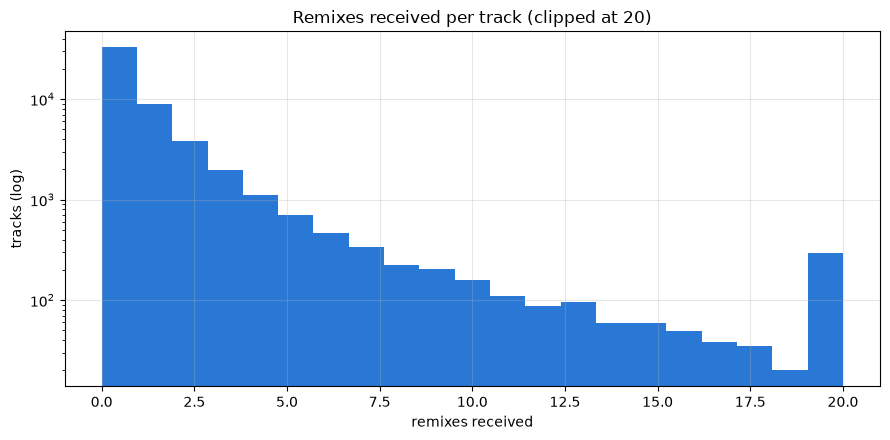

In [9]:
# heavy-tailed reuse
buckets = pd.cut(out_deg, [-1,0,1,2,5,10,25,10_000],
                 labels=["0","1","2","3-5","6-10","11-25","26+"])
display(buckets.value_counts().reindex(["0","1","2","3-5","6-10","11-25","26+"]).to_frame("tracks"))
print("share never remixed:", round((out_deg == 0).mean(), 4), "| max:", int(out_deg.max()))

# secondary outcome: spawned a further remix
spawn = set(local.loc[local["child_id"].isin(parents_local), "parent_id"]) & node_ids
print("spawned_further_remix base rate:", round(len(spawn)/N, 4), f"({len(spawn)})")

ax = out_deg.clip(upper=20).plot.hist(bins=21, color=BLUE, log=True)
ax.set_xlabel("remixes received"); ax.set_ylabel("tracks (log)")
ax.set_title("Remixes received per track (clipped at 20)")
plt.tight_layout(); plt.savefig(FIGDIR / "remixes_received.png", dpi=120); plt.show()

**Interpretation.**

**Label rule.** The outcome is taken from `edges.csv` (the track has at least one local child), never from the `n_remixes` counter. Every graph-positive has a real, dated child, and the time-based features and horizon labels in `03` need that date.

**Where the two sources disagree.** The counter reports 1,387 more remixed tracks (2.7 %) than the graph. The disagreement runs in one direction only.
- **Pool edges:** 14 of these tracks involve pool/off-site links.
- **No surviving child:** 1,373 have a counter value but no child in the crawl.
  - Only 41 of these are explained by the 684 time-inverted edges removed during cleaning.
  - The rest are most plausibly stale counters or deleted children. Almost all (1,295) involve a single remix.
- **Scale of the noise:** this label noise is bounded at 2.7 % and one-directional. Excluding these tracks leaves test AUC unchanged (0.842 → 0.843; see `04`).

**Local vs "all".** The "ALL" count (19,002) differs from the local count (18,766) only because of 236 tracks whose IDs collide with pool-item IDs. Pool items are never tracks, so a local+pool outcome is identical to the local outcome, and it is not used.

**Base rate and class balance.** 36.4 % of tracks were ever remixed, and 15.7 % spawned a second-generation remix. The classes are reasonably balanced, so no resampling is needed.

**Heavy tail.** Reuse is heavily skewed: 63.6 % of tracks are never remixed, while 169 tracks were remixed 26 or more times (maximum 493). This matches the concentration of reuse reported by Cheliotis & Yew and Calefato et al.

## 6. Graph structure — DAG, cascade depth, components

is DAG: True
depth distribution (our code): {0: 20258, 1: 23824, 2: 4744, 3: 1547, 4: 666, 5: 248, 6: 112, 7: 45, 8: 29, 9: 10, 10: 3}
summary.json local           : {'0': 20258, '1': 23824, '2': 4744, '3': 1547, '4': 666, '5': 248, '6': 112, '7': 45, '8': 29, '9': 10, '10': 3}

of tracks that are themselves remixes:
  depth 1 share          : 76.3%
  within two generations : 91.5%
  max depth              : 10


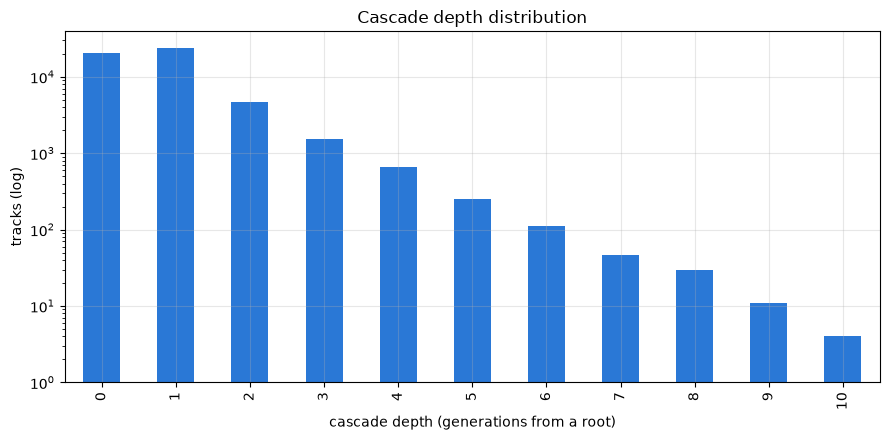

In [10]:
print("is DAG:", nx.is_directed_acyclic_graph(G))

# cascade depth = longest path from a root (topological pass)
depth = {}
for node in nx.topological_sort(G):
    preds = list(G.predecessors(node))
    depth[node] = 0 if not preds else 1 + max(depth[p] for p in preds)
depth = pd.Series(depth)

dist = depth.value_counts().sort_index()
print("depth distribution (our code):", dist.to_dict())
print("summary.json local           :", summary["variants"]["local"]["cascade_depth_distribution"])

in_lineage = depth[depth >= 1]
print("\nof tracks that are themselves remixes:")
print("  depth 1 share          :", f"{(in_lineage==1).mean()*100:.1f}%")
print("  within two generations :", f"{(in_lineage<=2).mean()*100:.1f}%")
print("  max depth              :", int(depth.max()))

ax = dist.plot.bar(color=BLUE, log=True)
ax.set_xlabel("cascade depth (generations from a root)"); ax.set_ylabel("tracks (log)")
ax.set_title("Cascade depth distribution")
plt.tight_layout(); plt.savefig(FIGDIR / "cascade_depth.png", dpi=120); plt.show()

In [11]:
# weakly-connected components: one giant remix network or many islands?
comp_sizes = pd.Series(sorted((len(c) for c in nx.weakly_connected_components(G)), reverse=True))
print("components:", len(comp_sizes))
print("largest component:", int(comp_sizes.iloc[0]), f"({comp_sizes.iloc[0]/N*100:.1f}% of tracks)")
print("singletons (size 1):", int((comp_sizes == 1).sum()))
display(comp_sizes.head(10).to_frame("component_size"))

components: 9797
largest component: 39280 (76.3% of tracks)
singletons (size 1): 8385


,component_size
0,39280
1,15
2,13
3,12
4,12
5,12
6,11
7,11
8,10
9,9


**Interpretation.**

**Integrity.** The cleaned local graph is a DAG, and our depth distribution matches `summary.json` exactly.

**Cascade depth.** Of the 31,228 tracks that are themselves remixes:
- 76.3 % sit one generation from an original,
- 91.5 % sit within two generations,
- the tail is thin and reaches depth 10 (3 tracks).

So the claim that remix cascades are "1–2 levels deep" is correct as a description of the typical case, not as a hard limit. The 20,258 tracks at depth 0 include both originals and unconnected uploads.

**Components.** There are 9,797 weakly connected components, but one giant component holds 39,280 tracks (76.3 % of all tracks). Most of the remaining components are singletons (8,385). The community therefore forms one large, interconnected reuse network rather than many isolated clusters.

The two 76.3 % figures are a numerical coincidence and measure different things.

## 7. Right-censoring / exposure — evidence for the horizon decision

A 2010 track has had ~15 years to attract a remix; a 2026 track has had weeks. So
`is_remixed = 0` on a recent track often means *"not remixed **yet**"*, not
*"unremixable"* — right-censoring. Left unhandled it teaches the model "old =
remixable". The plot below quantifies it so you can choose a horizon Δ and a
temporal cutoff in `03` from evidence, not by guessing.

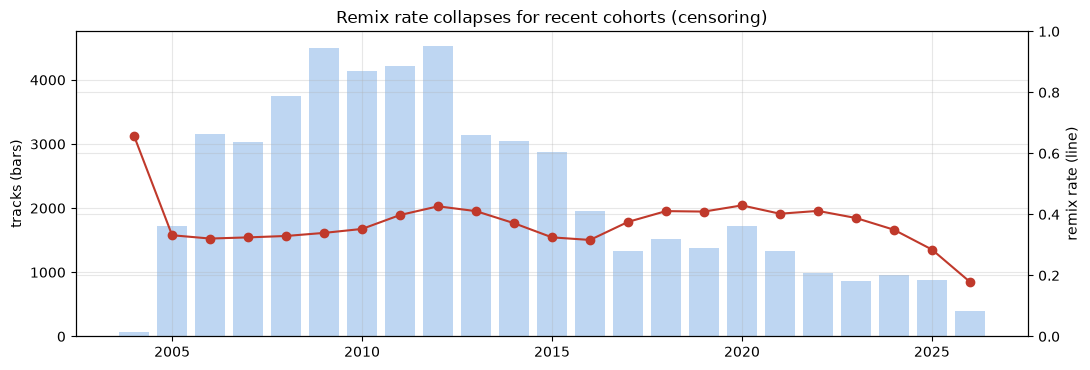

snapshot: 2026-07-20 21:30:00+00:00


,n,remix_rate
year,,
2019,1381,0.409124
2020,1714,0.429405
2021,1333,0.402101
2022,987,0.411348
2023,858,0.388112
2024,961,0.349636
2025,885,0.284746
2026,397,0.178841


In [12]:
snapshot = d.max()
exposure_days = (snapshot - d).dt.days
cohort = pd.DataFrame({"year": d.dt.year, "is_remixed": is_remixed.values})
by_yr = cohort.groupby("year").agg(n=("is_remixed","size"), remix_rate=("is_remixed","mean"))

fig, ax1 = plt.subplots(figsize=(11, 3.8))
ax1.bar(by_yr.index, by_yr.n, alpha=0.3, color=BLUE, label="tracks")
ax1.set_ylabel("tracks (bars)")
ax2 = ax1.twinx()
ax2.plot(by_yr.index, by_yr.remix_rate, marker="o", color=RED, label="remix rate")
ax2.set_ylabel("remix rate (line)"); ax2.set_ylim(0, 1)
ax1.set_title("Remix rate collapses for recent cohorts (censoring)")
plt.tight_layout(); plt.savefig(FIGDIR / "censoring_by_cohort.png", dpi=120); plt.show()

print("snapshot:", snapshot)
display(by_yr.tail(8))

**Interpretation.** Ever-remixed rates are stable at about 0.39–0.43 for tracks posted in 2019–2023. They then fall to 0.35 (2024), 0.28 (2025) and 0.18 (2026). This is right-censoring: recent tracks have not had time to be remixed.

**Decisions implemented in `03`:**
- **Primary horizon:** remixed within **365 days** of posting. Alternates of 180 and 730 days are reported for robustness.
- **Fair labelling:** a track is labelled for horizon H only if it was observed for at least H days before the crawl.
- **Temporal cutoff: 1 Jan 2022.**
  - Test set: tracks posted between 2022-01-01 and 2025-07-20 (n = 3,330).
  - Training set: tracks whose outcome window closed before the cutoff.
  - `04` makes the gap between training and test horizon-specific, so for 730 days the training data stop before 2020.

## 8. Removed edges — audit the cleaning decision

In [13]:
print("removed reasons:", removed["_removed_reason"].value_counts().to_dict())
r = removed.copy()
r["gap_days"] = (r["parent_date_unix"] - r["child_date_unix"]) / 86400
print("all removed have parent newer than child:",
      bool((r["parent_date_unix"] > r["child_date_unix"]).all()))
display(r["gap_days"].describe())
print("\nExample removed edges (same artist, tiny gaps => same-session uploads):")
display(r.sort_values("gap_days")[["parent_id","child_id","parent_user","gap_days"]].head(12))

removed reasons: {'time_inverted': 684}
all removed have parent newer than child: True


count     684.000000
mean      453.031040
std       449.211626
min         0.002083
25%        29.357465
50%       391.414583
75%       867.640451
max      2300.952083
Name: gap_days, dtype: float64


Example removed edges (same artist, tiny gaps => same-session uploads):


,parent_id,child_id,parent_user,gap_days
236,26443,26442,Norms_World,0.002083
170,29137,29134,Ezra Skull,0.002778
18,39177,39174,PattsiPeng,0.005556
89,35760,35759,SackJo22,0.005556
23,25926,25925,Haskel,0.006250
671,3527,3526,HC-7,0.008333
667,3528,3526,HC-7,0.008333
108,49803,49802,solos_to_use,0.010417
106,49286,49285,solos_to_use,0.015278
21,28031,28029,jlbrock44,0.016667


**Interpretation.** All 684 removed edges point backwards in time: the "parent" was posted after the "child". Such a link is impossible in a real lineage, and these edges were the only source of cycles.

The gaps are not mainly same-session uploads:
- 9 % of removed edges have a gap under 1 day,
- 25 % under 30 days,
- 51 % more than a year (median 391 days, maximum 2,301).

Only 1.9 % of removed edges link tracks by the same artist. The table above shows the smallest gaps only, so it is not representative. The label printed above the table ("same artist, tiny gaps") overstates this pattern.

The edges were **dropped rather than reversed**. That makes no claim about the true direction, which is the conservative choice. They are 1.1 % of all edges and explain only 41 of the 1,387 counter disagreements in §5.

## 9. Edge set — types, sources, integrity

In [14]:
print("edge_type:", edges["edge_type"].value_counts().to_dict())
print("source   :", edges["source"].value_counts().to_dict())
print("duplicate (parent,child):", int(edges.duplicated(["parent_id","child_id"]).sum()))
print("self-loops:", int((edges["parent_id"]==edges["child_id"]).sum()))
print("child not in nodes:", int((~edges["child_id"].isin(node_ids)).sum()))
print("parent not in nodes (pool/off-site parents):", int((~edges["parent_id"].isin(node_ids)).sum()))

edge_type: {'local': 59186, 'pool': 3114}
source   : {'embedded': 38876, 'query': 23424}
duplicate (parent,child): 0
self-loops: 0
child not in nodes: 0
parent not in nodes (pool/off-site parents): 2578


**Interpretation.** Edge integrity holds: there are no duplicate pairs, no self-loops, and no dangling child references.

**Edge types.** Of 62,300 edges, 59,186 are *local* (track → track, used for all analysis) and 3,114 are *pool* (off-site sample → track).

**Why the parent counts differ.** Only 2,578 edges have a parent outside the node table, even though there are 3,114 pool edges. The other 536 pool edges carry pool-item IDs that numerically coincide with track IDs. Pool and track IDs are separate numbering schemes, so pool edges must never be joined to tracks by ID.

**Crawl sources.** 38,876 edges came from source lists embedded in track records, and 23,424 from the separate query pass. These are two independent routes to the same links, and a bidirectional check on a 200-track sample found full agreement.

## 10. EDA summary — decisions carried into `02_preprocess`

- **Columns dropped:**
  - `user_id`, `year` and `num_playlists` (100 % null);
  - `thumbs_up` and `has_meta` (constant);
  - `score` (90 % null, undocumented).
- **Columns kept:** identifiers, dates, licence, `num_files`, `n_sources`, `usertags`, `systags`, `num_scores` (diagnostic only) and `n_remixes` (audit only).
- **Engagement signal:** `num_scores`, with nulls filled as 0 (a missing key means no ratings) and a flag recorded. It is a snapshot value and is **not** used as a feature.
- **Outcome:** the primary outcome is `is_remixed` (at least one local child), with a base rate of 36.4 %. The secondary outcome is `spawned_further_remix`, with a base rate of 15.7 %.
- **Label source:** the local edge graph, never `n_remixes`. They disagree for 1,387 tracks (2.7 %), always in one direction; see §5.
- **Edge definition:** local edges only. A local+pool variant adds no information for outcomes (pool items are not tracks) and is affected by ID collisions.
- **Horizon and cutoff:** 365 days (with 180 and 730 as alternates); cutoff 2022-01-01.
- **Author concentration:** 49 accounts (the top 1 %) produced 40.9 % of all tracks; this is quantified in `04`.
- **Data-quality caveats:**
  - 2.7 % of labels are one-directionally noisy;
  - 684 time-inverted edges were dropped;
  - recent years are sparse and right-censored;
  - the data are licensed CC BY-NC.

Next: **`02_preprocess`** applies these decisions, then **`03_features_split`** builds the temporal split and the leakage-safe features.